<a href="https://colab.research.google.com/github/Khushwant123-x/Medical_Insurance-ml-model-with-fastapi/blob/main/notebook221392901e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mosapabdelghany_medical_insurance_cost_dataset_path = kagglehub.dataset_download('mosapabdelghany/medical-insurance-cost-dataset')

print('Data source import complete.')


In [ ]:
import kagglehub
import os

# Path to the dataset folder
data_dir = "/kaggle/input/datasets/mosapabdelghany/medical-insurance-cost-dataset"

# List all files in the dataset directory
print(os.listdir(data_dir))


['insurance.csv']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(os.path.join(data_dir, "insurance.csv"))
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

<Axes: ylabel='sex'>

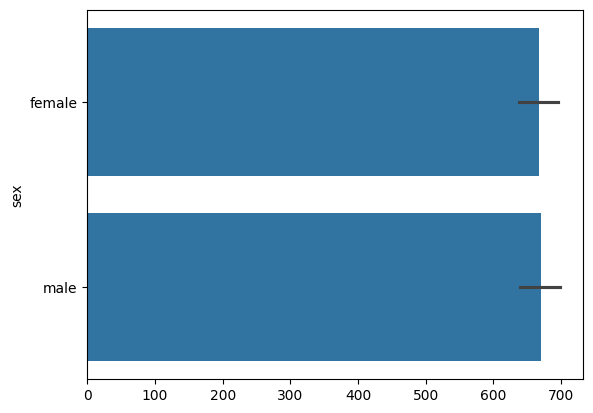

In [ ]:
sns.barplot(df["sex"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df["sex"] = df["sex"].map({"female":0, "male":1})
df["smoker"] = df["smoker"].map({"no":0, "yes":1})

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df = pd.get_dummies(df, columns=["region"], dtype=int)

In [ ]:
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


In [ ]:
df.duplicated().sum()

np.int64(1)

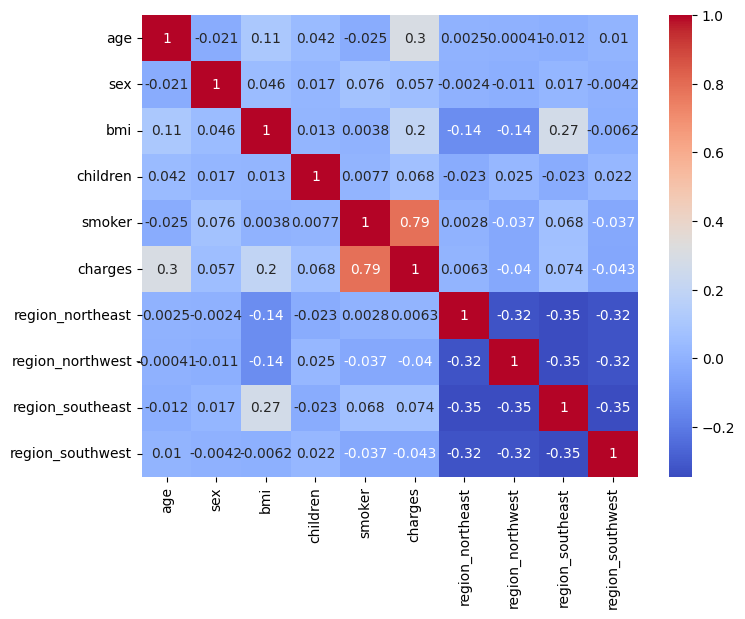

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

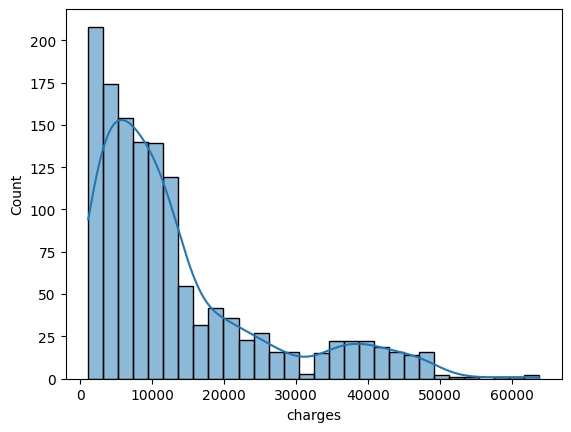

In [ ]:
sns.histplot(df["charges"], kde=True)
plt.show()

In [ ]:
df["charges"] = np.log1p(df["charges"])

In [ ]:
df["charges"]

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges, Length: 1338, dtype: float64

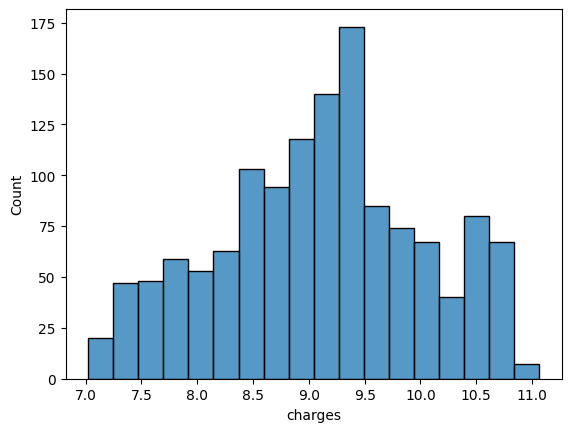

In [ ]:
sns.histplot(df["charges"])
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["bmi"] = scaler.fit_transform(df[["bmi"]])

In [ ]:
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,-0.453320,0,1,9.734236,0,0,0,1
1,18,1,0.509621,1,0,7.453882,0,0,1,0
2,28,1,0.383307,3,0,8.400763,0,0,1,0
3,33,1,-1.305531,0,0,9.998137,0,1,0,0
4,32,1,-0.292556,0,0,8.260455,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,0.050297,3,0,9.268755,0,1,0,0
1334,18,0,0.206139,0,0,7.699381,1,0,0,0
1335,18,0,1.014878,0,0,7.396847,0,0,1,0
1336,21,0,-0.797813,0,0,7.605365,0,0,0,1


In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train.shape

(1070, 9)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model = lr.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

print(f"r2:{r2_score(y_test,y_pred)}")

r2:0.804741079139302


In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgbr = XGBRegressor(
    n_estimators = 100,
    learning_rate =0.1,
    max_depth=3,
    random_state = 42
)

In [ ]:
xgbr.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgbr.predict(X_test)

In [ ]:
print(f"r2_xgbr:{r2_score(y_test,y_pred_xgb)}")

r2_xgbr:0.8669218921476177


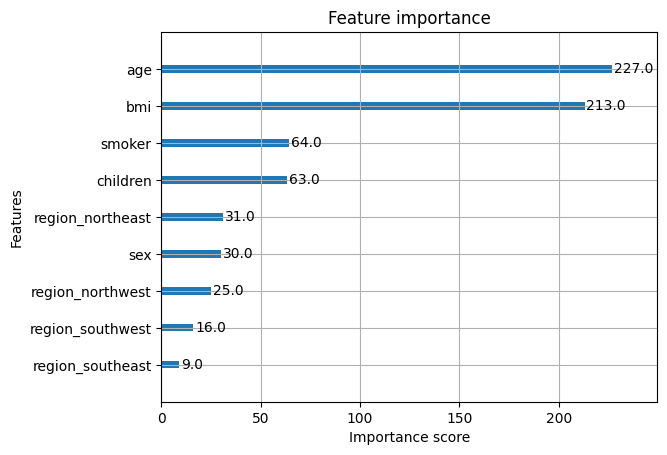

In [ ]:
from xgboost import plot_importance

plot_importance(xgbr)
plt.show()

In [ ]:
import joblib

joblib.dump(xgbr, "medical_insurance_xgboost.pkl")
joblib.dump(X_train.columns.tolist(), "medical_insurance_columns.pkl")
model = joblib.load("medical_insurance_xgboost.pkl")
columns = joblib.load("medical_insurance_columns.pkl")

print(columns)

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
